In [1]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google'

In [ ]:
import os
import numpy as np
import random
from PIL import Image, ImageEnhance
from tensorflow.keras.preprocessing.image import load_img, ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from sklearn.utils import shuffle

: 

In [ ]:
test_dir = '/content/drive/MyDrive/Colab Notebooks/MRI IMAGES/Testing'
train_dir = '/content/drive/MyDrive/Colab Notebooks/MRI IMAGES/Training'

In [ ]:
train_paths = []
train_labels = []
for label in os.listdir(train_dir):
    for image in os.listdir(os.path.join(train_dir, label)):
        train_paths.append(os.path.join(train_dir, label, image))
        train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

In [ ]:
test_paths = []
test_labels = []
for label in os.listdir(test_dir):
    for image in os.listdir(os.path.join(test_dir, label)):
        test_paths.append(os.path.join(test_dir, label, image))
        test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)

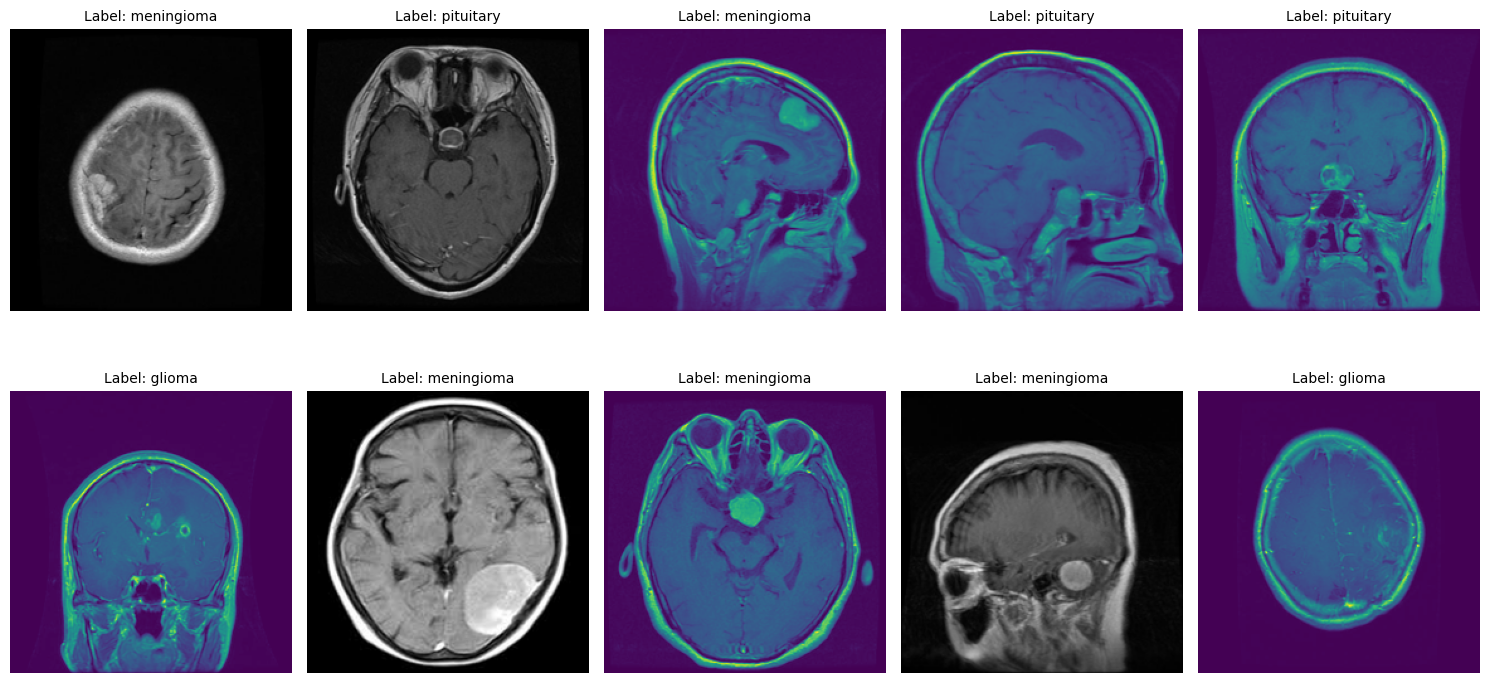

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os


random_indices = random.sample(range(len(train_paths)), 10)
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
axes = axes.ravel()

for i, idx in enumerate(random_indices):
    img_path = train_paths[idx]
    img = Image.open(img_path)
    img = img.resize((224, 224))
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f"Label: {train_labels[idx]}", fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))
    image = np.array(image) / 255.0
    return image

def open_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = augment_image(image)
        images.append(image)
    return np.array(images)

def encode_label(labels):
    unique_labels = os.listdir(train_dir)
    encoded = [unique_labels.index(label) for label in labels]
    return np.array(encoded)


def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)
            batch_labels = labels[i:i + batch_size]
            batch_labels = encode_label(batch_labels)
            yield batch_images, batch_labels

In [ ]:
IMAGE_SIZE = 128
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

for layer in base_model.layers:
    layer.trainable = False

base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))
model.add(base_model)
model.add(Flatten())
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(len(os.listdir(train_dir)), activation='softmax'))

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

batch_size = 20
steps = int(len(train_paths) / batch_size)
epochs = 7


history = model.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
                    epochs=epochs, steps_per_epoch=steps)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/7
285/285 ━━━━━━━━━━━━━━━━━━━━ 954s 3s/step - loss: 0.6747 - sparse_categorical_accuracy: 0.7295
Epoch 2/7
285/285 ━━━━━━━━━━━━━━━━━━━━ 43s 124ms/step - loss: 0.2530 - sparse_categorical_accuracy: 0.9026
Epoch 3/7
285/285 ━━━━━━━━━━━━━━━━━━━━ 35s 123ms/step - loss: 0.1587 - sparse_categorical_accuracy: 0.9400
Epoch 4/7
285/285 ━━━━━━━━━━━━━━━━━━━━ 35s 124ms/step - loss: 0.1184 - sparse_categorical_accuracy: 0.9555
Epoch 5/7
285/285 ━━━━━━━━━━━━━━━━━━━━ 34s 120ms/step - loss: 0.0801 - sparse_categorical_accuracy: 0.9736
Epoch 6/7
285/285 ━━━━━━━━━━━━━━━━━━━━ 34s 120ms/step - loss: 0.0731 - sparse_categorical_accuracy: 0.9785
Epoch 7/7
285/285 ━━━━━━━━━━━━━━━━━━━━ 33s 118ms/step - loss: 0.0589 - sparse_categorical_accuracy: 0.9798


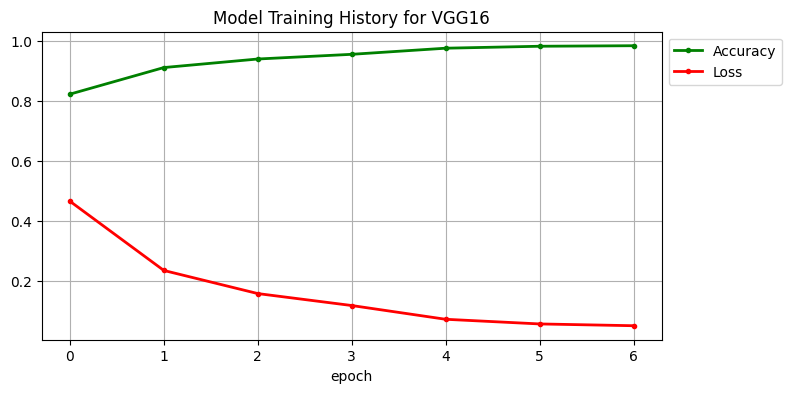

In [ ]:
plt.figure(figsize=(8,4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'], '.g-', linewidth=2)
plt.plot(history.history['loss'], '.r-', linewidth=2)
plt.title('Model Training History for VGG16')
plt.xlabel('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model
import numpy as np

# 1. Prediction on test data
test_images = open_images(test_paths)  # Load and augment test images
test_labels_encoded = encode_label(test_labels)  # Encode the test labels

# Predict using the trained model
test_predictions = model.predict(test_images)

# 2. Classification Report
print("Classification Report for VGG16:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))

41/41 ━━━━━━━━━━━━━━━━━━━━ 15s 220ms/step
Classification Report for VGG16:
              precision    recall  f1-score   support

           0       0.99      0.91      0.95       300
           1       0.95      0.98      0.96       300
           2       0.95      1.00      0.97       405
           3       0.92      0.90      0.91       306

    accuracy                           0.95      1311
   macro avg       0.95      0.95      0.95      1311
weighted avg       0.95      0.95      0.95      1311



In [ ]:
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[274   5   2  19]
 [  0 294   2   4]
 [  0   0 405   0]
 [  3  11  17 275]]


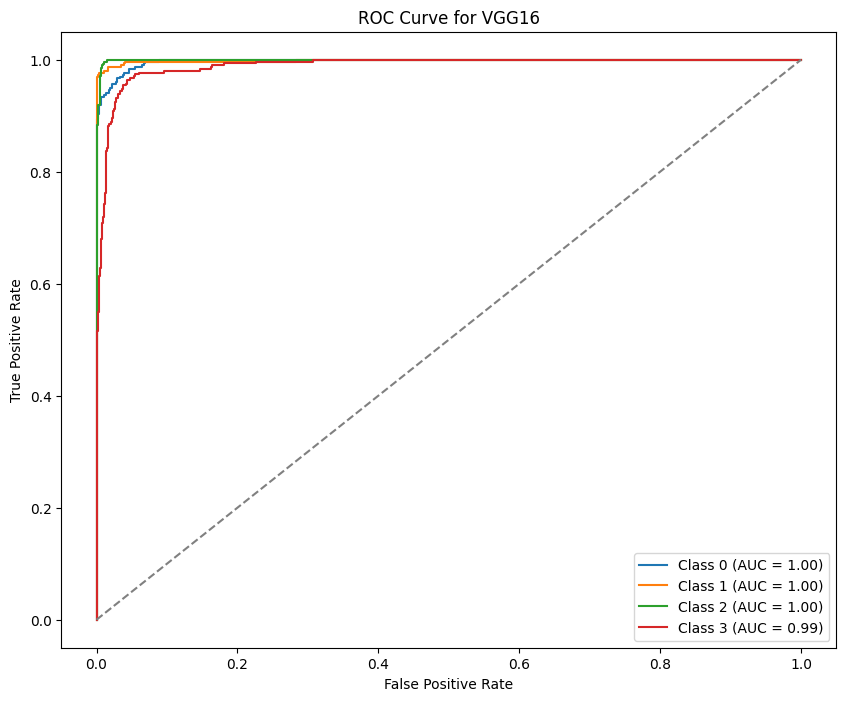

In [ ]:
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(len(os.listdir(train_dir))))
test_predictions_bin = test_predictions

fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(os.listdir(train_dir))):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
for i in range(len(os.listdir(train_dir))):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title("ROC Curve for VGG16")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

In [ ]:
model.save('model.h5')
from tensorflow.keras.models import load_model
model = load_model('model.h5')

In [ ]:
from keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt
from PIL import ImageDraw, ImageFont, Image

class_labels = ['pituitary', 'glioma', 'notumor', 'meningioma']

def detect_and_display(img_path, model, image_size=128):
    """
    Function to detect tumor and display results.
    If no tumor is detected, it displays "No Tumor".
    Otherwise, it shows the predicted tumor class and confidence.
    Modified to return the image with text overlay for Gradio.
    """
    try:
        img = load_img(img_path)
        img_resized = img.resize((image_size, image_size))
        img_array = img_to_array(img_resized) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions, axis=1)[0]
        confidence_score = np.max(predictions, axis=1)[0]

        if class_labels[predicted_class_index] == 'notumor':
            result_text = "No Tumor"
        else:
            result_text = f"Tumor: {class_labels[predicted_class_index]}"


        img_with_text = img.copy()
        draw = ImageDraw.Draw(img_with_text)
        try:

            font = ImageFont.truetype("arial.ttf", 25)
        except IOError:

            font = ImageFont.load_default()

        text_to_display = f"{result_text} (Confidence: {confidence_score * 100:.2f}%)"
        draw.text((10, 10), text_to_display, fill=(255, 0, 0), font=font)


        return img_with_text

    except Exception as e:
        print("Error processing the image:", str(e))
        return None

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


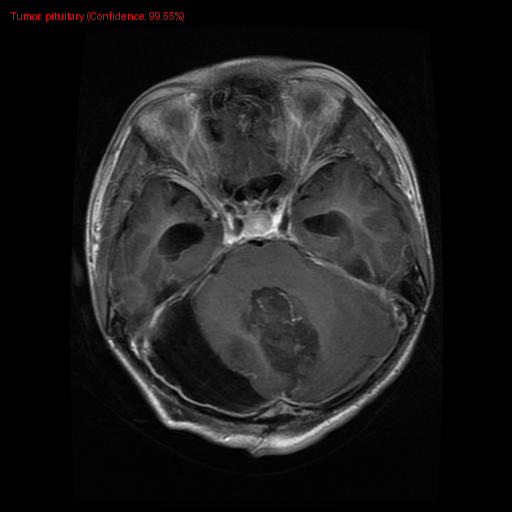

In [ ]:
detect_and_display('/content/drive/MyDrive/Colab Notebooks/MRI IMAGES/Testing/glioma/Te-glTr_0000.jpg',model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


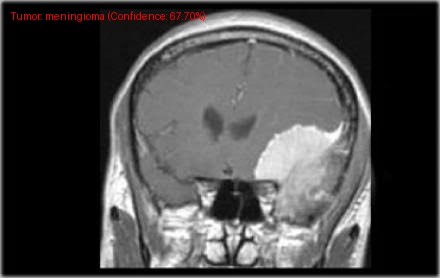

In [ ]:
detect_and_display('/content/drive/MyDrive/Colab Notebooks/MRI IMAGES/Testing/meningioma/Te-meTr_0000.jpg',model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


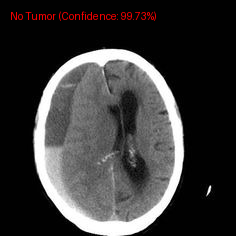

In [ ]:
detect_and_display('/content/drive/MyDrive/Colab Notebooks/MRI IMAGES/Testing/notumor/Te-noTr_0000.jpg',model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


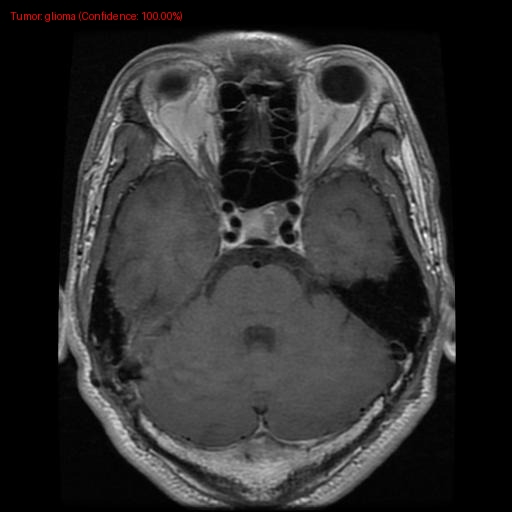

In [ ]:
detect_and_display('/content/drive/MyDrive/Colab Notebooks/MRI IMAGES/Testing/pituitary/Te-piTr_0000.jpg',model)